### Load Story and preprocess

In [ ]:
import os
from storyTools import loadStory,splitStoryEntity,cleanFragment

LANGUAGE = "english"  # Set the language to either "polish" or "english"
STORY_NAME = "story4.txt"  # Set the story file name

### Get and Clean Stories and Split to Two Entities 
[Story1,Story1_raw] = loadStory(STORY_NAME)
Story1_bundle = splitStoryEntity(Story1_raw)


story4.txt


Get Story Descriptive Stats

In [ ]:
import numpy as np
from assessmentFunctions import preprocess
story1FirstEntityClean = [];
story1SecondEntityClean = [];

wordStatsStory1 = np.zeros([len(Story1_bundle['firstEntity']),4]);

for i in range(len(Story1_bundle['firstEntity'])):
    story1FirstEntityClean.append(preprocess(Story1_bundle['firstEntity'][i],LANGUAGE))
    story1SecondEntityClean.append(preprocess(Story1_bundle['secondEntity'][i],LANGUAGE))


    wordStatsStory1[i,0] = len(story1FirstEntityClean[i])
    wordStatsStory1[i,1] = len("".join(story1FirstEntityClean[i]))
    wordStatsStory1[i,2] = len(story1SecondEntityClean[i])
    wordStatsStory1[i,3] = len("".join(story1SecondEntityClean[i]))


### (1) The Difference between story fragments in Descriptive stats

In [ ]:
import pandas as pd

dfWordStats = pd.DataFrame(wordStatsStory1, columns= ["FirstWords","FirstLetters","SecondWords","SecondLetters"])
from scipy.stats import wilcoxon,ranksums,ttest_ind,mannwhitneyu

res = mannwhitneyu(dfWordStats['FirstWords'].to_numpy(), dfWordStats['SecondWords'].to_numpy())
print(f"Difference Between Entity 1 and 2 with Word Count: z ={res[0]}, p = {res[1]}")
res2 = mannwhitneyu(dfWordStats['FirstLetters'].to_numpy(), dfWordStats['SecondLetters'].to_numpy())
print(f"Difference Between Entity 1 and 2 with Sign Count: z ={res2[0]}, p = {res2[1]}")

dfWordStats[['FirstWords','SecondWords','FirstLetters','SecondLetters']].describe()

Difference Between Entity 1 and 2 with Word Count: z =184.0, p = 0.6740470204304945
Difference Between Entity 1 and 2 with Sign Count: z =235.5, p = 0.3435608052342166


,FirstWords,SecondWords,FirstLetters,SecondLetters
count,20.000000,20.000000,20.000000,20.000000
mean,69.100000,69.900000,412.800000,395.250000
std,6.290343,5.533629,41.994486,40.751978
min,58.000000,59.000000,352.000000,309.000000
25%,65.500000,67.250000,380.750000,367.750000
50%,70.000000,70.000000,409.500000,403.500000
75%,72.250000,74.250000,437.500000,412.250000
max,83.000000,80.000000,496.000000,477.000000


The similarity and Overall Counts for both Entities

In [ ]:

from assessmentFunctions import cosineSim
cosSIM = cosineSim(". ".join(Story1_bundle['firstEntity']),". ".join(Story1_bundle['secondEntity']),LANGUAGE)
print()
print(f"Similarity between Stories: {cosSIM}")

dfWordStats


Similarity between Stories: 2.547688672309979


,FirstWords,FirstLetters,SecondWords,SecondLetters
0,69.0,369.0,74.0,416.0
1,71.0,390.0,70.0,359.0
2,58.0,362.0,65.0,367.0
3,68.0,384.0,68.0,338.0
4,68.0,371.0,75.0,407.0
5,72.0,428.0,75.0,411.0
6,75.0,478.0,73.0,407.0
7,66.0,386.0,59.0,309.0
8,72.0,474.0,71.0,392.0
9,70.0,428.0,65.0,395.0


<Axes: title={'center': 'Word Stats'}, xlabel='Entity', ylabel='Count'>

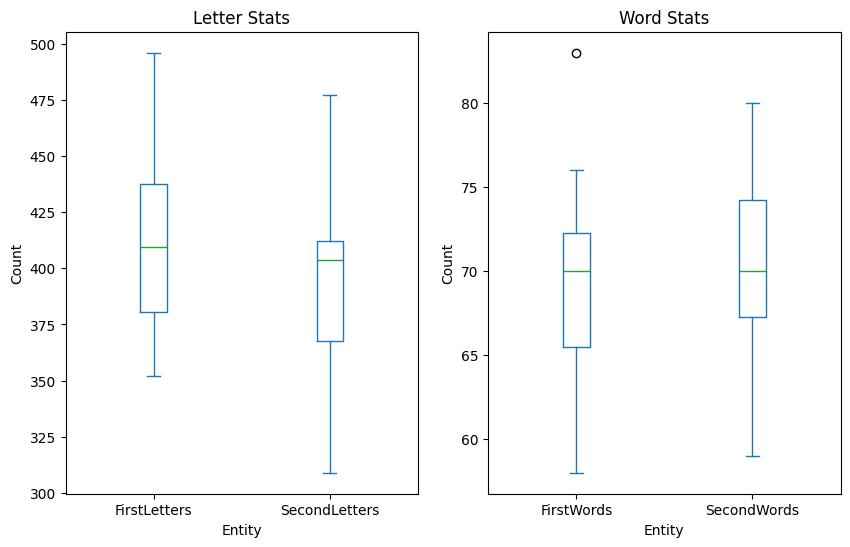

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

dfWordStats[['FirstLetters','SecondLetters']].plot(kind='box', title='Letter Stats', ylabel='Count', xlabel="Entity",ax=ax[0])
dfWordStats[['FirstWords','SecondWords']].plot(kind='box', title='Word Stats', ylabel='Count', xlabel="Entity",ax=ax[1])

### (2) Part-of-speech distribution uniformity

Checks for POS uniformity across both entities in the story


In [ ]:

if LANGUAGE == "polish":
    from assessmentFunctions import tagStoryPolish as tagStory
else:
    from assessmentFunctions import tagStoryEnglish as tagStory

SpeechTagged1 = dict(sorted(tagStory(Story1_bundle['firstEntity']).items()))
SpeechTagged2 = dict(sorted(tagStory(Story1_bundle['secondEntity']).items()))


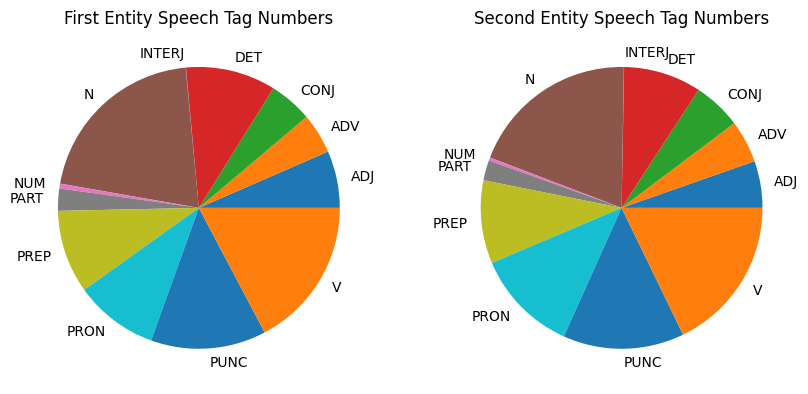

In [ ]:
# Import libraries
from matplotlib import pyplot as plt
import numpy as np

z = set(SpeechTagged1.keys()).intersection(set(SpeechTagged2.keys()))
SpeechTagged1 = {k: SpeechTagged1[k] for k in SpeechTagged1.keys() if k in z}
SpeechTagged2 = {k: SpeechTagged2[k] for k in SpeechTagged2.keys() if k in z}

# Creating dataset
keys1 = list(SpeechTagged1.keys());
keys1.sort()
data1 =[ len(SpeechTagged1[i]) for i in keys1 ]

keys2 = list(SpeechTagged2.keys());
keys2.sort()
data2 =[ len(SpeechTagged2[i]) for i in keys2 ]

# Creating plot
fig,ax = plt.subplots(1,2, figsize=(10, 5))
ax[0].set_title("First Entity Speech Tag Numbers")
ax[0].pie(data1, labels=keys1)
ax[1].set_title("Second Entity Speech Tag Numbers")
ax[1].pie(data2, labels=keys2)

# show plot
plt.show()

### (3) Lexical Diversity Metrics

#### Preprocessing

Getting Corpuses, Dictionairies, Modells and all other necessery part for Detailed analyses

In [ ]:
from sentence_transformers import SentenceTransformer,util
from IPython.display import clear_output
import spacy
# Load model ONCE
from nltk.corpus import cmudict
CMU_DICT = cmudict.dict()
model1 = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


from nltk import word_tokenize


### Novelty Score Adjacent Computation! Not Needed!!!!!
# import fasttext
# if LANGUAGE == "polish":
#     model = fasttext.load_model('.\\data\\cc.pl.300.bin')


#     path = ".\\NKJP3"
#     dirlist = os.listdir(path)
#     base_word_concepts = []
#     for i,fold in enumerate(dirlist):
#         progress = f"Processing Folder {i+1} of {len(dirlist)}: {fold}"
#         clear_output(wait=True)
#         print(progress)
#         if os.path.isfile(os.path.join(path,fold,"ann_words.xml")):
#             base_word_concepts += extract_base_forms(os.path.join(path,fold,"ann_words.xml"))
#         # Extract base word forms from the target XML file
#     clear_output(wait=True)
#     print(f"Done processing {len(dirlist)} folders.")
#     Conc = set(preprocess(" ".join(base_word_concepts),LANGUAGE)) # Get the Complete Word list of NAtural Corpus of Polish Langauge (NKJP)
# else:
#     Conc = set()
#     from nltk.corpus import brown
#     nlp = spacy.load("en_core_web_sm")
#     words = brown.words()
#     for word in brown.words():
#         if word.isalpha():
#             lemma = nlp(word)[0].lemma_.lower()
#             Conc.add(lemma)

In [ ]:
from assessmentFunctions import FOGScore,pisarekIndex,preprocess,shannon,bertSentenceCosineSim,lexical_diversity_storywise,count_syllables,dictStemmer,extract_base_forms


#from lexical_diversity import lex_div as ld

### Readability Index:
import re 
storyScores = np.zeros([6,len(Story1)])
for i,story in enumerate([Story1]):
    preprocessedSotry = preprocess(" ".join(story),LANGUAGE)
    for j,newCont in enumerate(story):

        print(f"\n Story: {i+1} Fragment: {j+1}")
        print(f" N. of Words: {len(newCont)}")

        storyScores[0,j] = FOGScore(newCont,LANGUAGE,CMU_DICT)
        print(f" FOG Gunmnan Score:        {storyScores[0,j]} ")
        storyScores[1,j] = lexical_diversity_storywise(preprocess(newCont,LANGUAGE),preprocessedSotry)
        #storyScores[1,j] =ld.hdd(preprocess(newCont))
        print(f" Lexical Diveristy Score:  {storyScores[1,j]}")
        storyScores[2,j]= pisarekIndex(newCont,LANGUAGE,CMU_DICT)
        print(f" Pisarek Read Score:       {storyScores[2,j]}")
        storyScores[3,j] = shannon(preprocess(newCont,LANGUAGE));
        print(f" Shannon Word Entropy:     {storyScores[3,j]}")
        storyScores[4,j] = bertSentenceCosineSim(newCont,newCont,model1,mode=0); #np.mean(bertCosineSim(newCont))
        print(f" Average Cosine DSI:       {storyScores[4,j]}")
        # storyScores[5,j] = noveltyScore(set(preprocess((newCont))),Conc);
        # print(f" Novelty Score:            {storyScores[5,j]}")




 Story: 1 Fragment: 1
 N. of Words: 667
 FOG Gunmnan Score:        3.942857142857143 
 Lexical Diveristy Score:  0.05619834710743802


TypeError: argument of type 'NoneType' is not iterable

In [ ]:
ddd = pd.DataFrame(storyScores, index=['FOG','Lexical Diversity','Pisarek Readability','Shannon Entropy','Average Cosine DSI','Novelty Score'], columns=[f"Fragment {i+1}" for i in range(len(Story1))]).T
ddd

,FOG,Lexical Diversity,Pisarek Readability,Shannon Entropy,Average Cosine DSI,Novelty Score
Fragment 1,8.058986,0.037082,76.774468,5.921938,0.832037,0.0
Fragment 2,6.238655,0.040729,89.714286,6.058051,0.834132,0.0
Fragment 3,6.048677,0.032219,89.958746,5.717850,0.835810,0.0
Fragment 4,4.797190,0.032827,98.114286,5.668442,0.835087,0.0
Fragment 5,6.064160,0.032827,88.198157,5.727627,0.835199,0.0
Fragment 6,6.123502,0.035258,86.402597,5.825164,0.835991,0.0
Fragment 7,4.727361,0.034650,85.625000,5.814846,0.832597,0.0
Fragment 8,4.253509,0.032827,95.417582,5.727627,0.831253,0.0
Fragment 9,6.333333,0.034043,88.375000,5.740224,0.831454,0.0
Fragment 10,5.738060,0.037082,90.594697,5.875718,0.838670,0.0


In [ ]:
karolina = ddd.iloc[::2].agg(['mean', 'std']).T
janek = ddd.iloc[1::2].agg(['mean', 'std']).T

summary = pd.concat([karolina, janek], axis=1, keys=['Karolina', 'Janek'])
summary

Karolina                Janek          
                          mean       std       mean       std
FOG                   5.874984  1.315592   5.382416  1.146979
Lexical Diversity     0.035319  0.002341   0.036383  0.003012
Pisarek Readability  83.951838  6.709362  90.392143  3.756262
Shannon Entropy       5.818295  0.111021   5.858789  0.128298
Average Cosine DSI    0.834506  0.002883   0.835503  0.002233
Novelty Score         0.000000  0.000000   0.000000  0.000000

Fog Gunman Score         ; z =   1.26; p =   0.2085; mean1 =     5.875; mean2 =     5.382
Lexical Diversity Score  ; z =  -1.27; p =   0.2036; mean1 =     0.035; mean2 =     0.036
Pisarek Score            ; z =  -3.22; p =   0.0013; mean1 =    83.952; mean2 =    90.392
Shannon Word Entropy     ; z =  -0.88; p =   0.3793; mean1 =     5.818; mean2 =     5.859
Average Cosine DSI       ; z =  -1.14; p =   0.2559; mean1 =     0.835; mean2 =     0.836


C:\Users\barak\AppData\Local\Temp\ipykernel_37932\1612032412.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(entityOneScores[idx], color="blue", ax=ax, label=None, alpha=0.7)
C:\Users\barak\AppData\Local\Temp\ipykernel_37932\1612032412.py:29: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(entityTwoScores[idx], color="orange", ax=ax, label=None, alpha=0.7)


Novelty Score            ; z =   0.00; p =   1.0000; mean1 =     0.000; mean2 =     0.000


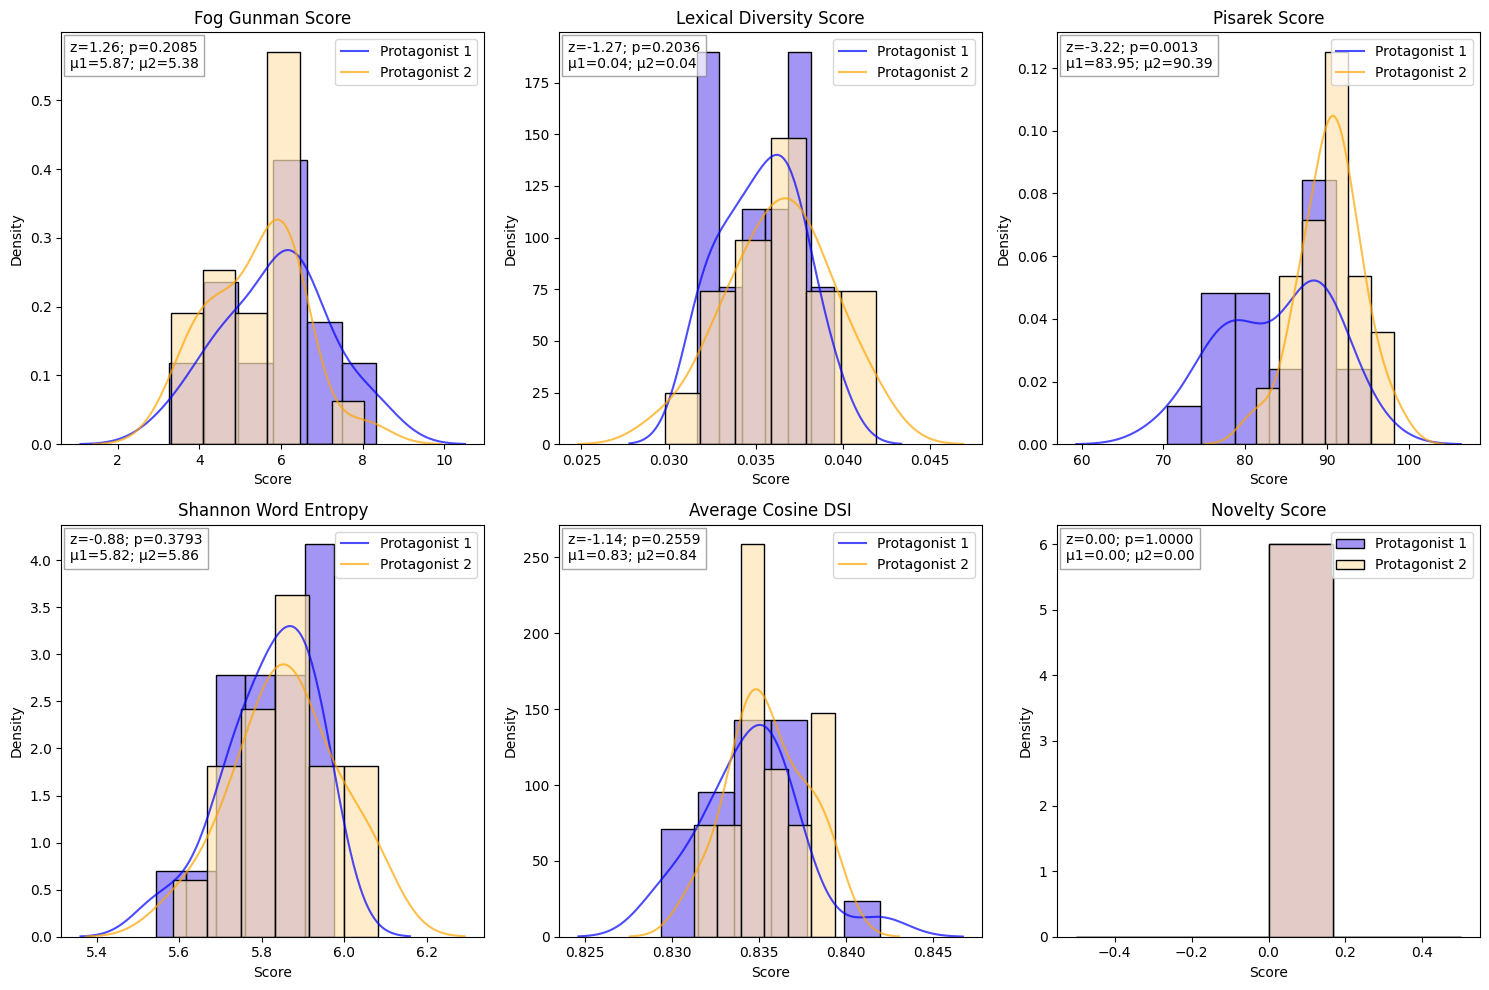

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

entityOneScores = storyScores[:,range(0,40,2)]
entityTwoScores = storyScores[:,range(1,40,2)]
labels = ["Protagonist 1", "Protagonist 2"]
colors = ['mediumslateblue', 'moccasin']
titles = [
    "Fog Gunman Score",
    "Lexical Diversity Score",
    "Pisarek Score",
    "Shannon Word Entropy",
    "Average Cosine DSI",
    "Novelty Score"
]

fig, axs = plt.subplots(2, 3, figsize=(15, 10))




for idx, ax in enumerate(axs.flat):
    ax.set_title(titles[idx])
    # Plot histograms as density (scaled)
    sns.histplot(entityOneScores[idx], bins=6, color=colors[0], ax=ax, label=labels[0], alpha=0.7, stat='density')
    sns.histplot(entityTwoScores[idx], bins=6, color=colors[1], ax=ax, label=labels[1], alpha=0.7, stat='density')
    # Overlay KDE lines with alpha and scaled
    sns.kdeplot(entityOneScores[idx], color="blue", ax=ax, label=None, alpha=0.7)
    sns.kdeplot(entityTwoScores[idx], color="orange", ax=ax, label=None, alpha=0.7)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    # Only show one legend per axis, not superimposed
    # Only show one legend per axis, not superimposed
    leg = ax.legend([labels[0], labels[1]], loc='upper right')
    res = ranksums(entityOneScores[idx,:], entityTwoScores[idx,:])
    mean1 = np.mean(entityOneScores[idx,:])
    mean2 = np.mean(entityTwoScores[idx,:])
    print(f"{titles[idx]:25s}; z = {res[0]:6.2f}; p = {res[1]:8.4f}; mean1 = {mean1:9.3f}; mean2 = {mean2:9.3f}")
    # Place the stats box in the left upper corner
    ax.text(0.02, 0.98, f"z={res[0]:.2f}; p={res[1]:.4f}\nμ1={mean1:.2f}; μ2={mean2:.2f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.show()